In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from skimage.segmentation import slic
from skimage.measure import regionprops
from skimage.feature import graycomatrix, graycoprops
import sys

BASE_PATH = Path(r'D:\proyecto_eutrofizacion')  # ← ajusta esto

sys.path.insert(0, str(BASE_PATH / 'src'))

from water_masc1 import segmentar_agua, calcular_metricas, visualizar_mascara_final
from water_masc2 import conectar_graffiti_y_cerrar, suavizar_bordes_contorno

# Parámetros de segmentación ya calibrados
PARAMETROS = {
    'a_min': -120, 'a_max': 1,
    'b_min': -120,  'b_max': 14,
    'l_min': 50,   'l_max': 255,
    'h_min': 22,   'h_max': 180,
    's_min': 0,    's_max': 110,
}

In [2]:
def seleccionar_imagenes(df, anio, n_imagenes):
    """
    Selecciona las primeras n_imagenes de un año específico.
    El CSV ya está ordenado correctamente.
    """
    df_anio = df[df['group'].astype(str) == str(anio)].copy()
    
    df_seleccion = df_anio.head(n_imagenes).reset_index(drop=True)
    
    print(f"Año {anio} — {len(df_anio)} imágenes disponibles")
    print(f"Seleccionadas: {len(df_seleccion)} (primeras {n_imagenes})")
    
    return df_seleccion


# PARÁMETROS A ELEGIR #
ANIO_ELEGIDO = 2019
N_IMAGENES = 18

df_river = pd.read_csv(BASE_PATH / 'data/metadata/river_water_index.csv')
df_seleccion = seleccionar_imagenes(df_river, ANIO_ELEGIDO, N_IMAGENES)

df_seleccion.head()

Año 2019 — 2025 imágenes disponibles
Seleccionadas: 18 (primeras 18)


,filepath,source,group,has_gps,site,segmentation_mask_path,mask_type,mask_format
0,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon
1,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon
2,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon
3,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon
4,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon


In [3]:
def extraer_caracteristicas_superpixeles(imagen, mascara_agua, n_segments=250):
    """
    Divide la región de agua en superpíxeles (SLIC) y calcula características
    de color y textura para cada uno.
    
    Parámetros:
    -----------
    imagen : np.ndarray (BGR)
    mascara_agua : np.ndarray (255=agua, 0=no-agua)
    n_segments : int
        Número aproximado de superpíxeles a generar sobre TODA la imagen
        (los que caigan fuera del agua se descartan después)
    
    Retorna:
    --------
    list[dict] : una fila por superpíxel con sus características
    """
    
    img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(imagen, cv2.COLOR_BGR2Lab)
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # SLIC sobre la imagen completa (RGB), luego filtramos por máscara de agua
    segments = slic(
        img_rgb,
        n_segments=n_segments,
        compactness=10,
        sigma=1,
        mask=(mascara_agua > 0)   # SLIC solo genera superpíxeles dentro del agua
    )
    
    filas = []
    
    for label in np.unique(segments):
        if label == 0:
            continue  # 0 = fondo (fuera de la máscara)
        
        region_mask = (segments == label)
        area = region_mask.sum()
        
        if area < 15:  # descarta superpíxeles minúsculos (ruido de borde)
            continue
        
        # --- Color promedio y variabilidad ---
        h_vals = hsv[:,:,0][region_mask]
        s_vals = hsv[:,:,1][region_mask]
        v_vals = hsv[:,:,2][region_mask]
        l_vals = lab[:,:,0][region_mask]
        a_vals = lab[:,:,1][region_mask].astype(np.float32) - 128
        b_vals = lab[:,:,2][region_mask].astype(np.float32) - 128
        
        # --- Textura simple (desviación estándar de gris = proxy de turbidez/rugosidad) ---
        gray_vals = gray[region_mask]
        textura_std = gray_vals.std()
        
        # --- Centroide (para ubicar la anomalía después en la imagen) ---
        ys, xs = np.where(region_mask)
        centroid_x = xs.mean()
        centroid_y = ys.mean()
        
        filas.append({
            'h_mean': h_vals.mean(), 'h_std': h_vals.std(),
            's_mean': s_vals.mean(), 's_std': s_vals.std(),
            'v_mean': v_vals.mean(), 'v_std': v_vals.std(),
            'l_mean': l_vals.mean(),
            'a_mean': a_vals.mean(),
            'b_mean': b_vals.mean(),
            'textura_std': textura_std,
            'area_px': int(area),
            'centroid_x': float(centroid_x),
            'centroid_y': float(centroid_y),
            'superpixel_label': int(label),
        })
    
    return filas


def construir_tabla_superpixeles(df_seleccion, base_path, parametros, n_segments=250):
    """
    - Segmenta agua en cada imagen
    - Extrae superpíxeles y características
    - Etiqueta cada superpíxel con su foto de origen
    - Devuelve una sola tabla con todo
    """

    todas_las_filas = []
    errores = []

    for idx, row in df_seleccion.iterrows():
        
        ruta_imagen = Path(base_path) / row['filepath']
        nombre_foto = Path(row['filepath']).name
        
        print(f"[{idx+1}/{len(df_seleccion)}] Procesando {nombre_foto}...")
        
        imagen = cv2.imread(str(ruta_imagen))
        if imagen is None:
            errores.append(nombre_foto)
            continue
        
        # --- Segmentación ---
        mascara_pred = segmentar_agua(imagen, **parametros, downscale=4, verbose=False)
        mascara_final = conectar_graffiti_y_cerrar(mascara_pred, skeleton_kernel=3, dilation_kernel=30)
        mascara_final = suavizar_bordes_contorno(mascara_final, contour_approx=7)
        
        if (mascara_final > 0).sum() < 500:
            print(f"  ⚠ Máscara de agua muy pequeña o vacía, se omite")
            continue
        
        # --- Superpíxeles + características (Etapas 2-3) ---
        filas_imagen = extraer_caracteristicas_superpixeles(
            imagen, mascara_final, n_segments=n_segments
        )
        
        # --- Etiqueta cada fila con su foto de origen (PASO 3) ---
        for fila in filas_imagen:
            fila['foto_origen'] = nombre_foto
            fila['anio'] = row['group']
        
        todas_las_filas.extend(filas_imagen)
        print(f"  ✓ {len(filas_imagen)} superpíxeles extraídos")

    df_tabla = pd.DataFrame(todas_las_filas)

    # ID único de superpíxel dentro de la tabla completa
    df_tabla.insert(0, 'superpixel_id', range(1, len(df_tabla) + 1))

    print(f"\n{'='*60}")
    print(f"Tabla final: {len(df_tabla)} superpíxeles de {df_seleccion.shape[0] - len(errores)} imágenes")
    if errores:
        print(f"Imágenes con error: {errores}")
    print(f"{'='*60}")

    return df_tabla

In [4]:
# Ejecuta el pipeline
import matplotlib.pyplot as plt

df_superpixeles = construir_tabla_superpixeles(
    df_seleccion,
    base_path=BASE_PATH,
    parametros=PARAMETROS,
    n_segments=250
)

df_superpixeles.head(10)

[1/18] Procesando DJI_11.JPG...
  ✓ 248 superpíxeles extraídos
[2/18] Procesando DJI_12.JPG...
  ✓ 250 superpíxeles extraídos
[3/18] Procesando DJI_13.JPG...
  ✓ 249 superpíxeles extraídos
[4/18] Procesando DJI_14.JPG...
  ✓ 250 superpíxeles extraídos
[5/18] Procesando DJI_15.JPG...
  ✓ 250 superpíxeles extraídos
[6/18] Procesando DJI_16.JPG...
  ✓ 250 superpíxeles extraídos
[7/18] Procesando DJI_17.JPG...
  ✓ 249 superpíxeles extraídos
[8/18] Procesando DJI_18.JPG...
  ✓ 251 superpíxeles extraídos
[9/18] Procesando DJI_19.JPG...
  ✓ 248 superpíxeles extraídos
[10/18] Procesando DJI_20.JPG...
  ✓ 247 superpíxeles extraídos
[11/18] Procesando DJI_21.JPG...
  ✓ 249 superpíxeles extraídos
[12/18] Procesando DJI_22.JPG...
  ✓ 249 superpíxeles extraídos
[13/18] Procesando DJI_23.JPG...
  ✓ 249 superpíxeles extraídos
[14/18] Procesando DJI_24.JPG...
  ✓ 245 superpíxeles extraídos
[15/18] Procesando DJI_25.JPG...
  ✓ 249 superpíxeles extraídos
[16/18] Procesando DJI_26.JPG...
  ✓ 250 superpíx

,superpixel_id,h_mean,h_std,s_mean,s_std,v_mean,v_std,l_mean,a_mean,b_mean,textura_std,area_px,centroid_x,centroid_y,superpixel_label,foto_origen,anio
0,1,96.294598,2.533810,49.957049,8.528832,146.594466,16.721472,144.990250,-6.462187,-5.935968,16.453010,3795,42.968906,21.725165,1,DJI_11.JPG,2019
1,2,95.802258,1.754591,44.233124,5.746210,153.722208,15.233338,153.195985,-6.331242,-5.187453,15.262581,3985,132.072020,24.989711,2,DJI_11.JPG,2019
2,3,96.845916,1.969550,46.287859,5.657959,151.263355,13.221686,149.791170,-5.977042,-5.754967,13.100748,4530,195.644812,42.023841,3,DJI_11.JPG,2019
3,4,96.186082,1.864180,38.781959,4.860994,159.683505,14.239333,159.314433,-5.459794,-4.795103,14.175147,3880,255.439948,26.167526,4,DJI_11.JPG,2019
4,5,96.359193,1.811927,38.349466,3.512872,158.964887,10.397495,158.707473,-5.355635,-4.775801,10.448232,4215,338.356109,27.108422,5,DJI_11.JPG,2019
5,6,95.915152,2.292503,34.135714,4.552577,163.507576,15.689677,164.067100,-5.151948,-4.182467,15.641387,4620,412.496537,30.695455,6,DJI_11.JPG,2019
6,7,96.060341,2.305547,32.597441,4.173936,163.799360,14.447465,164.677186,-4.928145,-3.947122,14.337721,4690,489.088486,29.008742,7,DJI_11.JPG,2019
7,8,95.226651,2.209787,34.046216,4.027799,161.708069,14.444869,162.721356,-5.349894,-3.941460,14.154292,5193,571.860582,31.335644,8,DJI_11.JPG,2019
8,9,97.284266,1.954789,34.158606,5.066066,168.289124,17.073920,167.810348,-4.679620,-4.687645,17.052217,4735,654.382471,27.580148,9,DJI_11.JPG,2019
9,10,95.892794,2.477530,33.696065,4.499560,164.341291,16.182010,164.912025,-5.114279,-4.177056,15.965168,4524,744.087533,28.875332,10,DJI_11.JPG,2019


In [5]:
OUTPUT_DIR = BASE_PATH / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

nombre_archivo = f"superpixeles_anio{ANIO_ELEGIDO}_n{N_IMAGENES}.csv"
ruta_salida = OUTPUT_DIR / nombre_archivo

df_superpixeles.to_csv(ruta_salida, index=False)

print(f"✓ Tabla guardada en: {ruta_salida}")
print(f"  Filas: {len(df_superpixeles)}")
print(f"  Columnas: {list(df_superpixeles.columns)}")

✓ Tabla guardada en: D:\proyecto_eutrofizacion\data\processed\superpixeles_anio2019_n18.csv
  Filas: 4483
  Columnas: ['superpixel_id', 'h_mean', 'h_std', 's_mean', 's_std', 'v_mean', 'v_std', 'l_mean', 'a_mean', 'b_mean', 'textura_std', 'area_px', 'centroid_x', 'centroid_y', 'superpixel_label', 'foto_origen', 'anio']


# Cargar y trabajar con tabla creada de superpíxeles

In [6]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import seaborn as sns

CARACTERISTICAS_DETECCION = [
    'h_mean', 'h_std',          # Tono y variabilidad
    's_mean', 's_std',          # Saturación y variabilidad
    'v_mean', 'v_std',          # Brillo y variabilidad
    'l_mean',                   # Luminancia Lab
    'a_mean',                   # Eje verde-rojo
    'b_mean',                   # Eje azul-amarillo
    'textura_std',              # Turbidez/rugosidad
]

X = df_superpixeles[CARACTERISTICAS_DETECCION].copy()

print(f"Features para detección: {len(CARACTERISTICAS_DETECCION)}")
print(f"Superpíxeles: {len(X)}")
print(f"\nEstadísticas de features:")
print(X.describe())

Features para detección: 10
Superpíxeles: 4483

Estadísticas de features:
            h_mean        h_std       s_mean        s_std       v_mean  \
count  4483.000000  4483.000000  4483.000000  4483.000000  4483.000000   
mean     81.739842     7.382596    24.084812     5.263169   130.096954   
std      23.968468     6.274044    12.284895     2.675246    16.836368   
min      23.048067     1.064919     4.526494     0.994698    63.780137   
25%      64.236393     2.761173    14.828963     3.369328   118.352303   
50%      94.148573     4.562514    21.080395     4.659086   127.471468   
75%     100.288698    10.400926    30.909286     6.441820   141.596436   
max     106.016700    30.699218    65.533386    24.792046   182.930483   

             v_std       l_mean       a_mean       b_mean  textura_std  
count  4483.000000  4483.000000  4483.000000  4483.000000  4483.000000  
mean      8.699356   134.085538    -2.628664    -1.285434     8.623307  
std       3.622955    17.289370     1.42

## Isolation Forest

In [ ]:
# Normaliza las características (importante para Isolation Forest)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# Entrena Isolation Forest
# contamination = porcentaje esperado de anomalías (ajusta según necesidad)
    iso_forest = IsolationForest(
        contamination=0.1,
        random_state=42,
        n_estimators=100
    )

# Predice: -1 = anomalía, 1 = normal
predicciones = iso_forest.fit_predict(X_escalado)

# Score de anomalía: más negativo = más anómalo
scores_anomalia = iso_forest.score_samples(X_escalado)

# Añade los resultados a la tabla
df_superpixeles['anomalia'] = predicciones  # -1 o 1
df_superpixeles['score_anomalia'] = scores_anomalia  # valores negativos = más raro

# Ordena por anomalía (más raro primero)
df_superpixeles_ordenado = df_superpixeles.sort_values('score_anomalia', ascending=True)

print(f"Anomalías detectadas: {(df_superpixeles['anomalia'] == -1).sum()}")
print(f"Normal: {(df_superpixeles['anomalia'] == 1).sum()}")

Anomalías detectadas: 449
Normal: 4034


In [8]:
# TOP 10 superpíxeles más anómalos
print("TOP 10 SUPERPÍXELES MÁS ANÓMALOS:")
print("="*80)

top_anomalas = df_superpixeles_ordenado.head(10)

for idx, row in top_anomalas.iterrows():
    print(f"\nSuperpíxel ID: {row['superpixel_id']}")
    print(f"  Foto origen: {row['foto_origen']}")
    print(f"  Score anomalía: {row['score_anomalia']:.4f}")
    print(f"  Posición en foto: ({row['centroid_x']:.0f}, {row['centroid_y']:.0f})")
    print(f"  Color Lab: L={row['l_mean']:.1f}, a*={row['a_mean']:.1f}, b*={row['b_mean']:.1f}")
    print(f"  Saturación: {row['s_mean']:.1f}")
    print(f"  Textura (turbidez): {row['textura_std']:.2f}")

TOP 10 SUPERPÍXELES MÁS ANÓMALOS:

Superpíxel ID: 132
  Foto origen: DJI_11.JPG
  Score anomalía: -0.7494
  Posición en foto: (3741, 118)
  Color Lab: L=88.2, a*=-10.5, b*=5.5
  Saturación: 65.5
  Textura (turbidez): 21.27

Superpíxel ID: 1057
  Foto origen: DJI_15.JPG
  Score anomalía: -0.7429
  Posición en foto: (4660, 804)
  Color Lab: L=74.2, a*=-7.5, b*=2.0
  Saturación: 62.0
  Textura (turbidez): 17.14

Superpíxel ID: 1543
  Foto origen: DJI_17.JPG
  Score anomalía: -0.7389
  Posición en foto: (4770, 884)
  Color Lab: L=71.2, a*=-6.9, b*=1.7
  Saturación: 59.5
  Textura (turbidez): 16.52

Superpíxel ID: 1824
  Foto origen: DJI_18.JPG
  Score anomalía: -0.7371
  Posición en foto: (4991, 1433)
  Color Lab: L=64.4, a*=-7.4, b*=3.7
  Saturación: 62.1
  Textura (turbidez): 14.90

Superpíxel ID: 2311
  Foto origen: DJI_20.JPG
  Score anomalía: -0.7344
  Posición en foto: (5140, 1930)
  Color Lab: L=72.6, a*=-8.4, b*=4.5
  Saturación: 62.8
  Textura (turbidez): 14.35

Superpíxel ID: 770

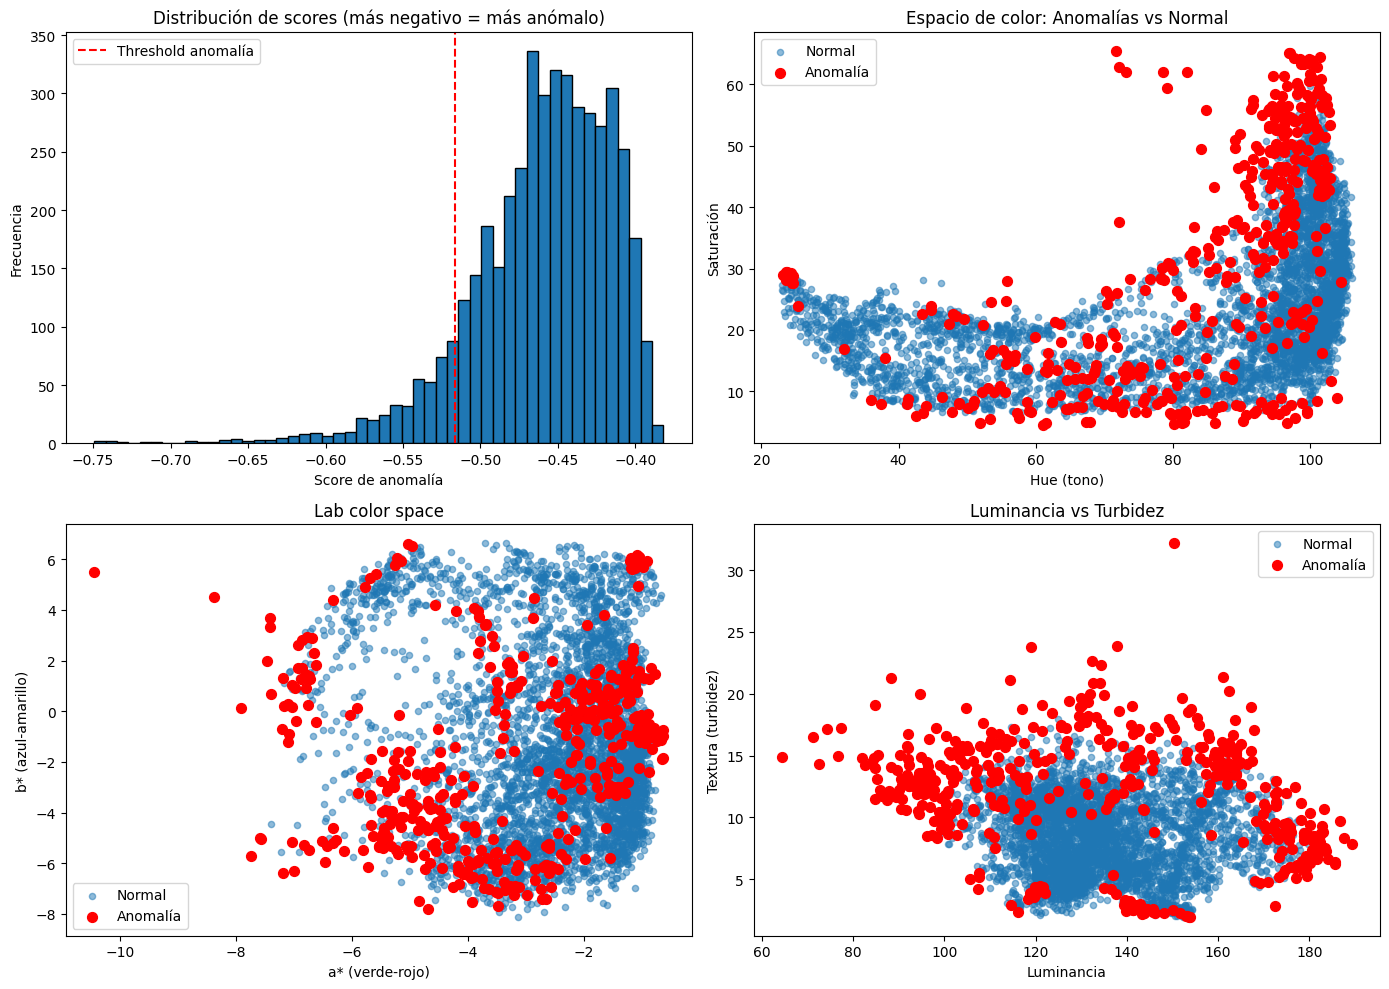

In [9]:
# Gráfico 1: Distribución de scores de anomalía
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Score de anomalía
axes[0, 0].hist(df_superpixeles['score_anomalia'], bins=50, edgecolor='black')
axes[0, 0].axvline(df_superpixeles[df_superpixeles['anomalia'] == -1]['score_anomalia'].max(), 
                   color='red', linestyle='--', label='Threshold anomalía')
axes[0, 0].set_xlabel('Score de anomalía')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de scores (más negativo = más anómalo)')
axes[0, 0].legend()

# Saturación: anomalías vs normal
axes[0, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == 1]['h_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == 1]['s_mean'],
                   alpha=0.5, label='Normal', s=20)
axes[0, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == -1]['h_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == -1]['s_mean'],
                   color='red', label='Anomalía', s=50)
axes[0, 1].set_xlabel('Hue (tono)')
axes[0, 1].set_ylabel('Saturación')
axes[0, 1].set_title('Espacio de color: Anomalías vs Normal')
axes[0, 1].legend()

# Lab a* vs b*
axes[1, 0].scatter(df_superpixeles[df_superpixeles['anomalia'] == 1]['a_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == 1]['b_mean'],
                   alpha=0.5, label='Normal', s=20)
axes[1, 0].scatter(df_superpixeles[df_superpixeles['anomalia'] == -1]['a_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == -1]['b_mean'],
                   color='red', label='Anomalía', s=50)
axes[1, 0].set_xlabel('a* (verde-rojo)')
axes[1, 0].set_ylabel('b* (azul-amarillo)')
axes[1, 0].set_title('Lab color space')
axes[1, 0].legend()

# Textura vs Luminancia
axes[1, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == 1]['l_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == 1]['textura_std'],
                   alpha=0.5, label='Normal', s=20)
axes[1, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == -1]['l_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == -1]['textura_std'],
                   color='red', label='Anomalía', s=50)
axes[1, 1].set_xlabel('Luminancia')
axes[1, 1].set_ylabel('Textura (turbidez)')
axes[1, 1].set_title('Luminancia vs Turbidez')
axes[1, 1].legend()

plt.tight_layout()
plt.show()